# Экспериментальная проверка теоретических формул сложности алгоритмов сортировки

Цель: реализовать алгоритмы сортировки со встроенными счётчиками сравнений,
запустить их на массивах размера $n = 2^k$ ($k = 1, \ldots, 14$)
и сопоставить эмпирическое число сравнений с замкнутыми формулами из Документов 02 и 03.

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

SIZES = [2**k for k in range(1, 15)]  # 2 .. 16384

---
## 1. Реализации алгоритмов (с подсчётом сравнений)

Каждая функция возвращает `(отсортированный_массив, число_сравнений)`.

### 1.1 Odd-Even Merge Sort (Бэтчер)

In [2]:
def odd_even_merge(arr, lo, hi, comparisons):
    """Odd-Even Merge на подмассиве arr[lo..hi-1] (две отсортированные половины)."""
    n = hi - lo
    if n <= 1:
        return
    if n == 2:
        comparisons[0] += 1
        if arr[lo] > arr[lo + 1]:
            arr[lo], arr[lo + 1] = arr[lo + 1], arr[lo]
        return

    even = [arr[lo + i] for i in range(0, n, 2)]
    odd  = [arr[lo + i] for i in range(1, n, 2)]

    odd_even_merge(even, 0, len(even), comparisons)
    odd_even_merge(odd,  0, len(odd),  comparisons)

    for i in range(len(even)):
        arr[lo + 2 * i]     = even[i]
    for i in range(len(odd)):
        arr[lo + 2 * i + 1] = odd[i]

    for i in range(1, n - 1, 2):
        comparisons[0] += 1
        if arr[lo + i] > arr[lo + i + 1]:
            arr[lo + i], arr[lo + i + 1] = arr[lo + i + 1], arr[lo + i]


def odd_even_merge_sort(arr, lo, hi, comparisons):
    n = hi - lo
    if n <= 1:
        return
    mid = lo + n // 2
    odd_even_merge_sort(arr, lo, mid, comparisons)
    odd_even_merge_sort(arr, mid, hi, comparisons)
    odd_even_merge(arr, lo, hi, comparisons)


def batcher_sort(data):
    arr = list(data)
    c = [0]
    odd_even_merge_sort(arr, 0, len(arr), c)
    return arr, c[0]

### 1.2 Bitonic Sort

In [3]:
def bitonic_compare(arr, i, j, ascending, comparisons):
    comparisons[0] += 1
    if (arr[i] > arr[j]) == ascending:
        arr[i], arr[j] = arr[j], arr[i]


def bitonic_merge(arr, lo, n, ascending, comparisons):
    if n <= 1:
        return
    half = n // 2
    for i in range(lo, lo + half):
        bitonic_compare(arr, i, i + half, ascending, comparisons)
    bitonic_merge(arr, lo, half, ascending, comparisons)
    bitonic_merge(arr, lo + half, half, ascending, comparisons)


def bitonic_sort_rec(arr, lo, n, ascending, comparisons):
    if n <= 1:
        return
    half = n // 2
    bitonic_sort_rec(arr, lo, half, True, comparisons)
    bitonic_sort_rec(arr, lo + half, half, False, comparisons)
    bitonic_merge(arr, lo, n, ascending, comparisons)


def bitonic_sort(data):
    arr = list(data)
    c = [0]
    bitonic_sort_rec(arr, 0, len(arr), True, c)
    return arr, c[0]

### 1.3 Merge Sort

In [4]:
def merge_sort_count(data):
    comparisons = [0]

    def _sort(arr):
        if len(arr) <= 1:
            return arr
        mid = len(arr) // 2
        left  = _sort(arr[:mid])
        right = _sort(arr[mid:])
        return _merge(left, right)

    def _merge(left, right):
        result = []
        i = j = 0
        while i < len(left) and j < len(right):
            comparisons[0] += 1
            if left[i] <= right[j]:
                result.append(left[i])
                i += 1
            else:
                result.append(right[j])
                j += 1
        result.extend(left[i:])
        result.extend(right[j:])
        return result

    sorted_arr = _sort(list(data))
    return sorted_arr, comparisons[0]

### 1.4 Quick Sort

In [5]:
import sys
sys.setrecursionlimit(50000)


def quicksort_count(data, pivot_strategy='random'):
    """pivot_strategy: 'random' | 'first' (worst-case на отсортированных данных)."""
    arr = list(data)
    comparisons = [0]

    def _qsort(lo, hi):
        if lo >= hi:
            return
        if pivot_strategy == 'random':
            pi = random.randint(lo, hi)
            arr[lo], arr[pi] = arr[pi], arr[lo]
        pivot = arr[lo]
        i = lo + 1
        j = hi
        while True:
            while i <= j:
                comparisons[0] += 1
                if arr[i] > pivot:
                    break
                i += 1
            else:
                i = j + 1
            while j >= i:
                comparisons[0] += 1
                if arr[j] < pivot:
                    break
                j -= 1
            else:
                j = i - 1
            if i > j:
                break
            arr[i], arr[j] = arr[j], arr[i]
            i += 1
            j -= 1
        arr[lo], arr[j] = arr[j], arr[lo]
        _qsort(lo, j - 1)
        _qsort(j + 1, hi)

    _qsort(0, len(arr) - 1)
    return arr, comparisons[0]

### 1.5 Insertion Sort

In [6]:
def insertion_sort_count(data):
    arr = list(data)
    comparisons = 0
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0:
            comparisons += 1
            if arr[j] > key:
                arr[j + 1] = arr[j]
                j -= 1
            else:
                break
        arr[j + 1] = key
    return arr, comparisons

### 1.6 Heap Sort

In [7]:
def heap_sort_count(data):
    arr = list(data)
    n = len(arr)
    comparisons = [0]

    def sift_down(start, end):
        root = start
        while True:
            child = 2 * root + 1
            if child > end:
                break
            if child + 1 <= end:
                comparisons[0] += 1
                if arr[child] < arr[child + 1]:
                    child += 1
            comparisons[0] += 1
            if arr[root] < arr[child]:
                arr[root], arr[child] = arr[child], arr[root]
                root = child
            else:
                break

    for start in range(n // 2 - 1, -1, -1):
        sift_down(start, n - 1)

    for end in range(n - 1, 0, -1):
        arr[0], arr[end] = arr[end], arr[0]
        sift_down(0, end - 1)

    return arr, comparisons[0]

### 1.7 Stooge Sort

In [8]:
def stooge_sort_count(data):
    arr = list(data)
    comparisons = [0]

    def _stooge(lo, hi):
        comparisons[0] += 1
        if arr[lo] > arr[hi]:
            arr[lo], arr[hi] = arr[hi], arr[lo]
        if hi - lo + 1 >= 3:
            t = (hi - lo + 1) // 3
            _stooge(lo, hi - t)
            _stooge(lo + t, hi)
            _stooge(lo, hi - t)

    if len(arr) >= 2:
        _stooge(0, len(arr) - 1)
    return arr, comparisons[0]

---
## 2. Теоретические формулы

In [9]:
def harmonic(n):
    return sum(1.0 / k for k in range(1, n + 1))


def theory_batcher_sort(n):
    """S(n) = n*log2(n)*(log2(n)-1)/4 + n - 1  (Документ 02, §4.3)"""
    m = math.log2(n)
    return n * m * (m - 1) / 4 + n - 1


def theory_bitonic_sort(n):
    """S_B(n) = n*log2(n)*(log2(n)+1)/4  (Документ 03, §4.4)"""
    m = math.log2(n)
    return n * m * (m + 1) / 4


def theory_merge_sort(n):
    """Худший случай Merge Sort: T(n) = n*log2(n) - n + 1 при n = 2^m.
    На случайных данных реальное число чуть ниже."""
    if n <= 1:
        return 0
    return n * math.log2(n) - n + 1


def theory_quicksort_worst(n):
    """T(n) = n*(n+1)/2 - 1  — при pivot = первый на отсортированном входе (Документ 03, §2.1).
    Hoare partition делает n сравнений на первом уровне (n-1 основных + 1 «перекрёстное»)."""
    return n * (n + 1) / 2 - 1


def theory_quicksort_avg(n):
    """T(n) = 2(n+1)*H_n - 4n  (Документ 03, §2.3)"""
    if n <= 1:
        return 0
    return 2 * (n + 1) * harmonic(n) - 4 * n


def theory_insertion_worst(n):
    """T(n) = n*(n-1)/2  (Документ 03, §6)"""
    return n * (n - 1) / 2


def theory_heap_sort(n):
    """Верхняя оценка: sum_{i=1}^{n-1} 2*floor(log2(i))
    (sift_down может делать до 2*log2(i) сравнений на шаг).
    Документ 03, §3: T(n) = O(n) + sum O(log i)."""
    total = 0
    for i in range(n // 2 - 1, -1, -1):
        h = math.floor(math.log2(n)) - math.floor(math.log2(i + 1)) if i >= 0 else 0
        total += 2 * h
    for i in range(n - 1, 0, -1):
        total += 2 * math.floor(math.log2(i))
    return total


def theory_stooge_sort(n):
    """T(n) ~ C * n^(log_{3/2}(3))  (Документ 03, §5.3)
    Точная рекуррентность: T(n)=3*T(ceil(2n/3))+1, T(2)=1, T(1)=0."""
    cache = {}
    def t(sz):
        if sz <= 1:
            return 0
        if sz == 2:
            return 1
        if sz in cache:
            return cache[sz]
        sub = sz - sz // 3
        cache[sz] = 3 * t(sub) + 1
        return cache[sz]
    return t(n)

---
## 3. Эксперименты

In [10]:
random.seed(42)
np.random.seed(42)

results = {
    'batcher':        {'emp': [], 'theory': []},
    'bitonic':        {'emp': [], 'theory': []},
    'merge':          {'emp': [], 'theory': []},
    'quick_worst':    {'emp': [], 'theory': []},
    'quick_avg':      {'emp': [], 'theory': []},
    'insertion':      {'emp': [], 'theory': []},
    'heap':           {'emp': [], 'theory': []},
    'stooge':         {'emp': [], 'theory': []},
}

STOOGE_LIMIT = 2**10  # Stooge Sort слишком медленный для больших n
INSERTION_LIMIT = 2**14

NUM_TRIALS = 5  # усреднение для случайных алгоритмов

for n in SIZES:
    data_random  = list(np.random.permutation(n))
    data_sorted  = list(range(n))
    data_reverse = list(range(n - 1, -1, -1))

    # --- Batcher (сортировочная сеть — число сравнений фиксировано) ---
    _, c = batcher_sort(data_random)
    results['batcher']['emp'].append(c)
    results['batcher']['theory'].append(theory_batcher_sort(n))

    # --- Bitonic Sort (фиксированная сеть) ---
    _, c = bitonic_sort(data_random)
    results['bitonic']['emp'].append(c)
    results['bitonic']['theory'].append(theory_bitonic_sort(n))

    # --- Merge Sort (на случайных данных) ---
    _, c = merge_sort_count(data_random)
    results['merge']['emp'].append(c)
    results['merge']['theory'].append(theory_merge_sort(n))

    # --- QuickSort worst (первый элемент как pivot, отсортированный вход) ---
    _, c = quicksort_count(data_sorted, pivot_strategy='first')
    results['quick_worst']['emp'].append(c)
    results['quick_worst']['theory'].append(theory_quicksort_worst(n))

    # --- QuickSort average (случайный pivot, усреднение) ---
    total_c = 0
    for _ in range(NUM_TRIALS):
        _, c = quicksort_count(data_random, pivot_strategy='random')
        total_c += c
    results['quick_avg']['emp'].append(total_c / NUM_TRIALS)
    results['quick_avg']['theory'].append(theory_quicksort_avg(n))

    # --- Insertion Sort worst (обратно отсортированный вход) ---
    if n <= INSERTION_LIMIT:
        _, c = insertion_sort_count(data_reverse)
        results['insertion']['emp'].append(c)
        results['insertion']['theory'].append(theory_insertion_worst(n))

    # --- Heap Sort ---
    _, c = heap_sort_count(data_random)
    results['heap']['emp'].append(c)
    results['heap']['theory'].append(theory_heap_sort(n))

    # --- Stooge Sort ---
    if n <= STOOGE_LIMIT:
        _, c = stooge_sort_count(data_random)
        results['stooge']['emp'].append(c)
        results['stooge']['theory'].append(theory_stooge_sort(n))

    print(f'n = {n:>6d}  done')

print('\nВсе эксперименты завершены.')

n =      2  done
n =      4  done
n =      8  done
n =     16  done
n =     32  done
n =     64  done
n =    128  done
n =    256  done
n =    512  done
n =   1024  done
n =   2048  done
n =   4096  done
n =   8192  done
n =  16384  done

Все эксперименты завершены.


---
## 4. Сравнительные графики: эмпирика vs теория

In [11]:
def plot_comparison(sizes, empirical, theoretical, title, formula_label):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    ax1.plot(sizes, empirical, 'o-', label='Эмпирика', markersize=4)
    ax1.plot(sizes, theoretical, 's--', label=f'Теория: {formula_label}', markersize=4)
    ax1.set_xlabel('n')
    ax1.set_ylabel('Число сравнений')
    ax1.legend()
    ax1.set_title('Линейная шкала')
    ax1.grid(True, alpha=0.3)

    ax2.plot(sizes, empirical, 'o-', label='Эмпирика', markersize=4)
    ax2.plot(sizes, theoretical, 's--', label=f'Теория: {formula_label}', markersize=4)
    ax2.set_xlabel('n')
    ax2.set_ylabel('Число сравнений')
    ax2.set_xscale('log', base=2)
    ax2.set_yscale('log', base=2)
    ax2.legend()
    ax2.set_title('Лог-лог шкала (основание 2)')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### 4.1 Odd-Even Merge Sort (Бэтчер)

Формула: $S(n) = \frac{n \log_2 n (\log_2 n - 1)}{4} + n - 1$

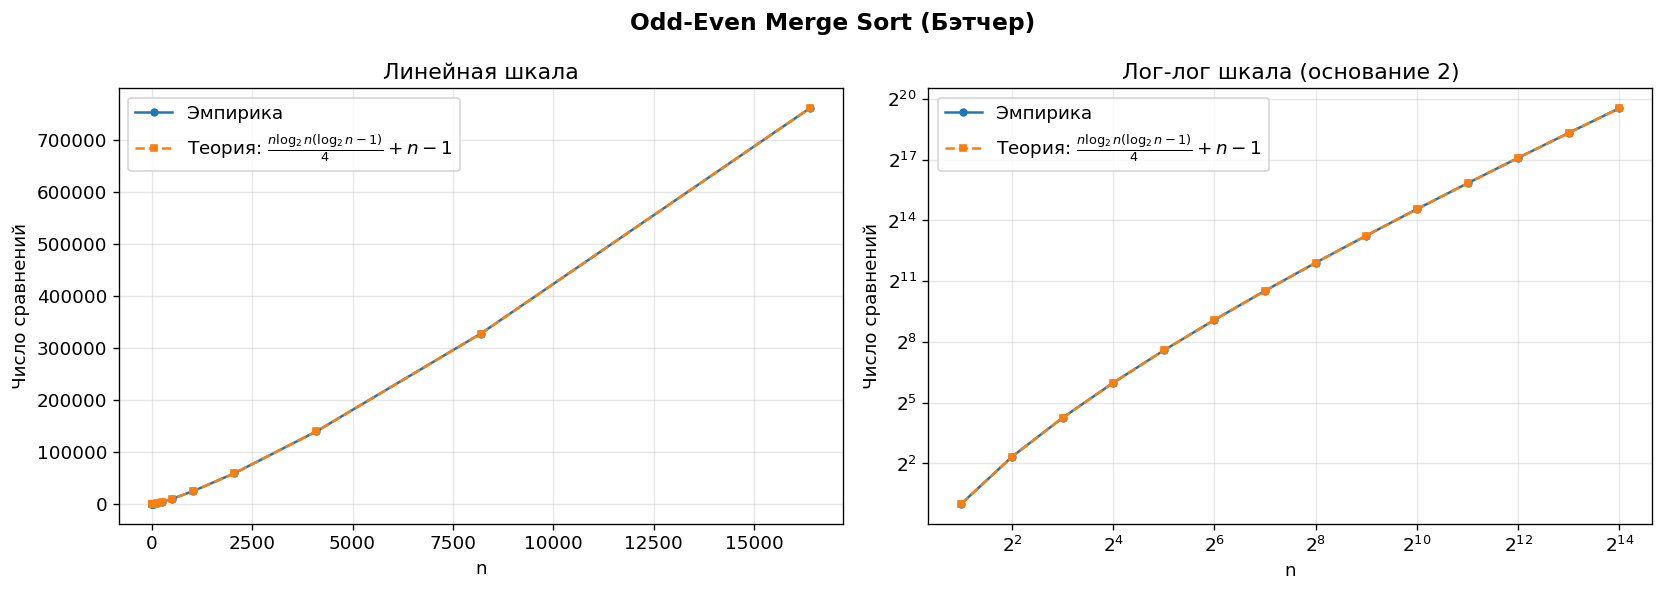

In [12]:
plot_comparison(
    SIZES,
    results['batcher']['emp'],
    results['batcher']['theory'],
    'Odd-Even Merge Sort (Бэтчер)',
    r'$\frac{n \log_2 n (\log_2 n - 1)}{4} + n - 1$'
)

### 4.2 Bitonic Sort

Формула: $S_B(n) = \frac{n \log_2 n (\log_2 n + 1)}{4}$

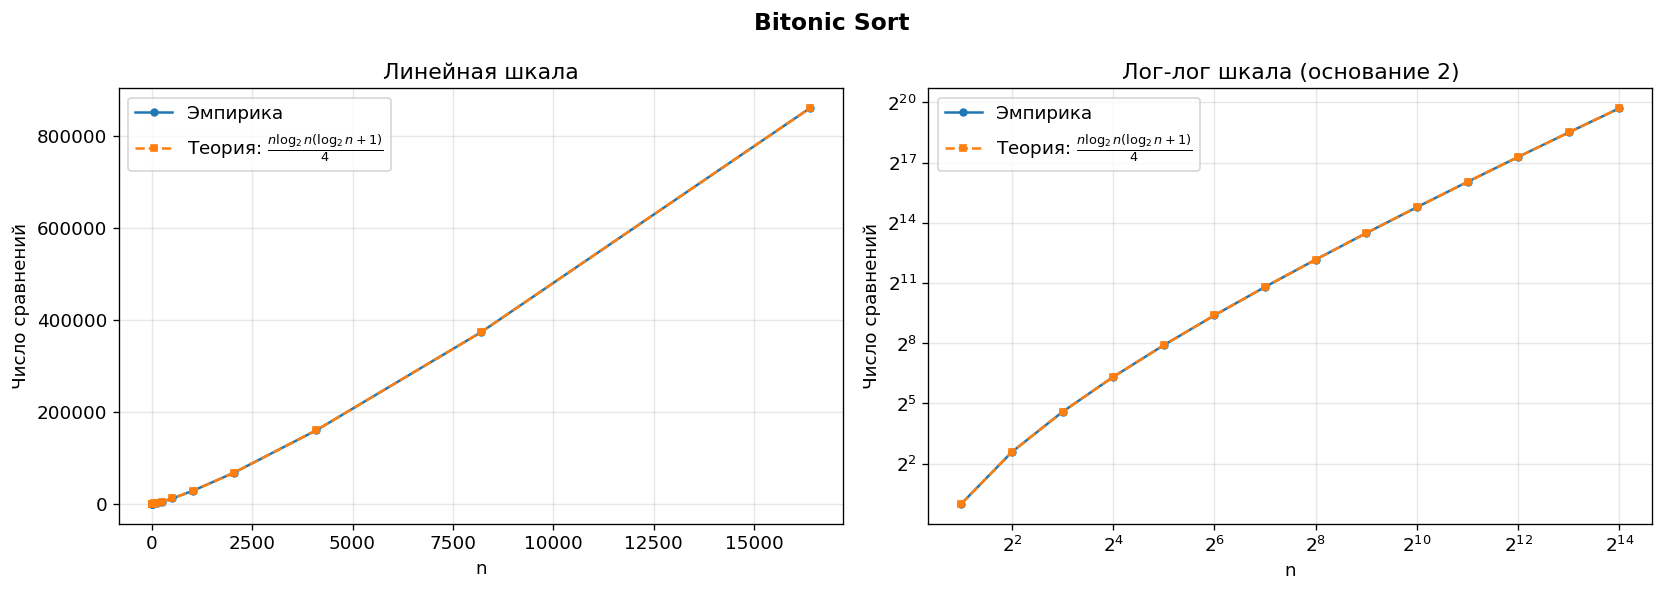

In [13]:
plot_comparison(
    SIZES,
    results['bitonic']['emp'],
    results['bitonic']['theory'],
    'Bitonic Sort',
    r'$\frac{n \log_2 n (\log_2 n + 1)}{4}$'
)

### 4.3 Merge Sort

Формула: $T(n) \approx n \log_2 n - n + 1$

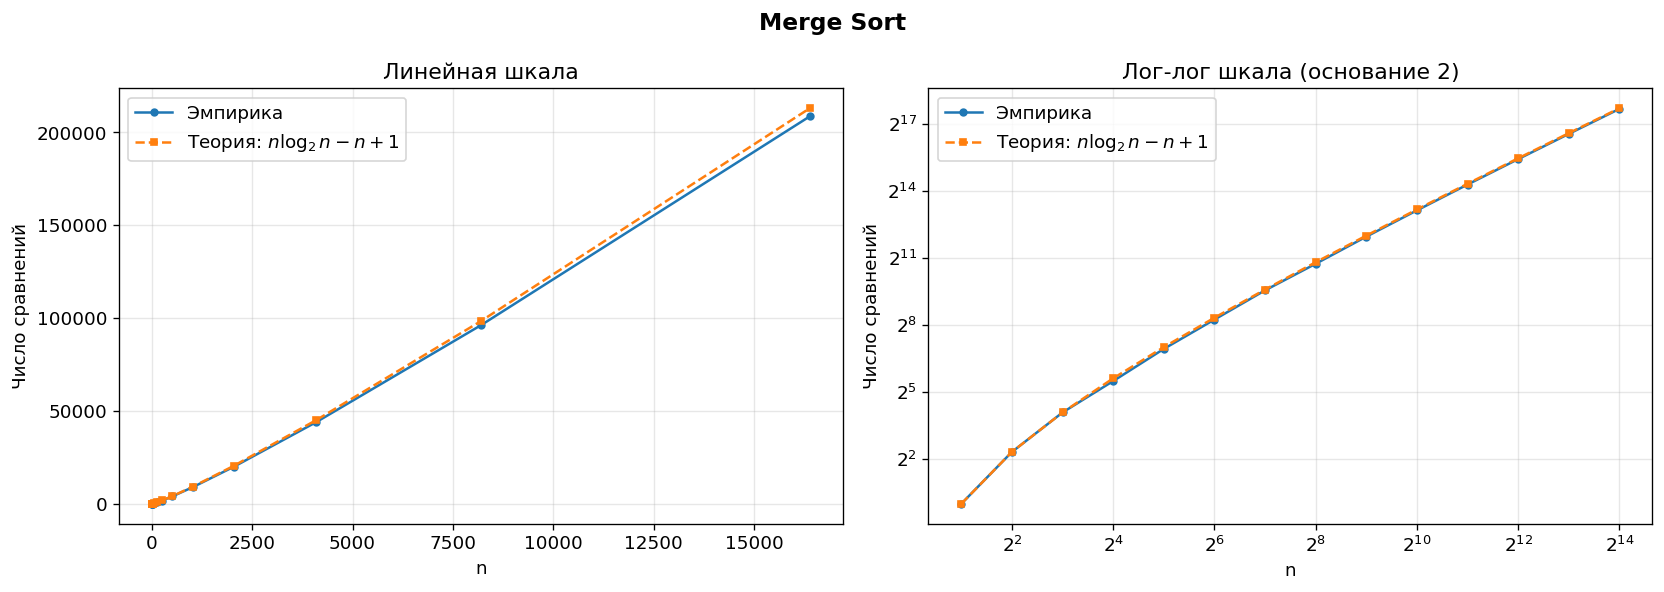

In [14]:
plot_comparison(
    SIZES,
    results['merge']['emp'],
    results['merge']['theory'],
    'Merge Sort',
    r'$n \log_2 n - n + 1$'
)

### 4.4 QuickSort — худший случай

Формула: $T(n) = \frac{n(n+1)}{2} - 1$ (отсортированный вход, pivot = первый элемент)

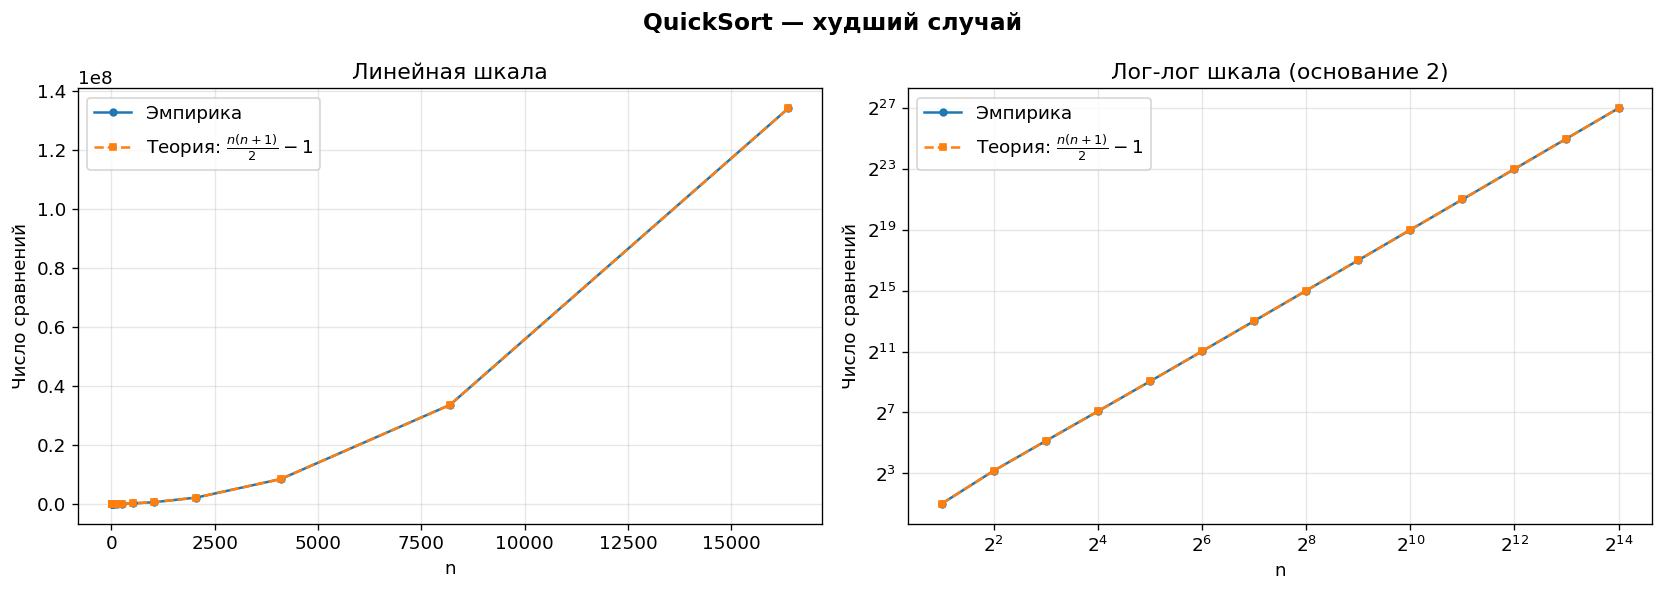

In [15]:
plot_comparison(
    SIZES,
    results['quick_worst']['emp'],
    results['quick_worst']['theory'],
    'QuickSort — худший случай',
    r'$\frac{n(n+1)}{2} - 1$'
)

### 4.5 QuickSort — средний случай

Формула: $T(n) = 2(n+1)H_n - 4n$

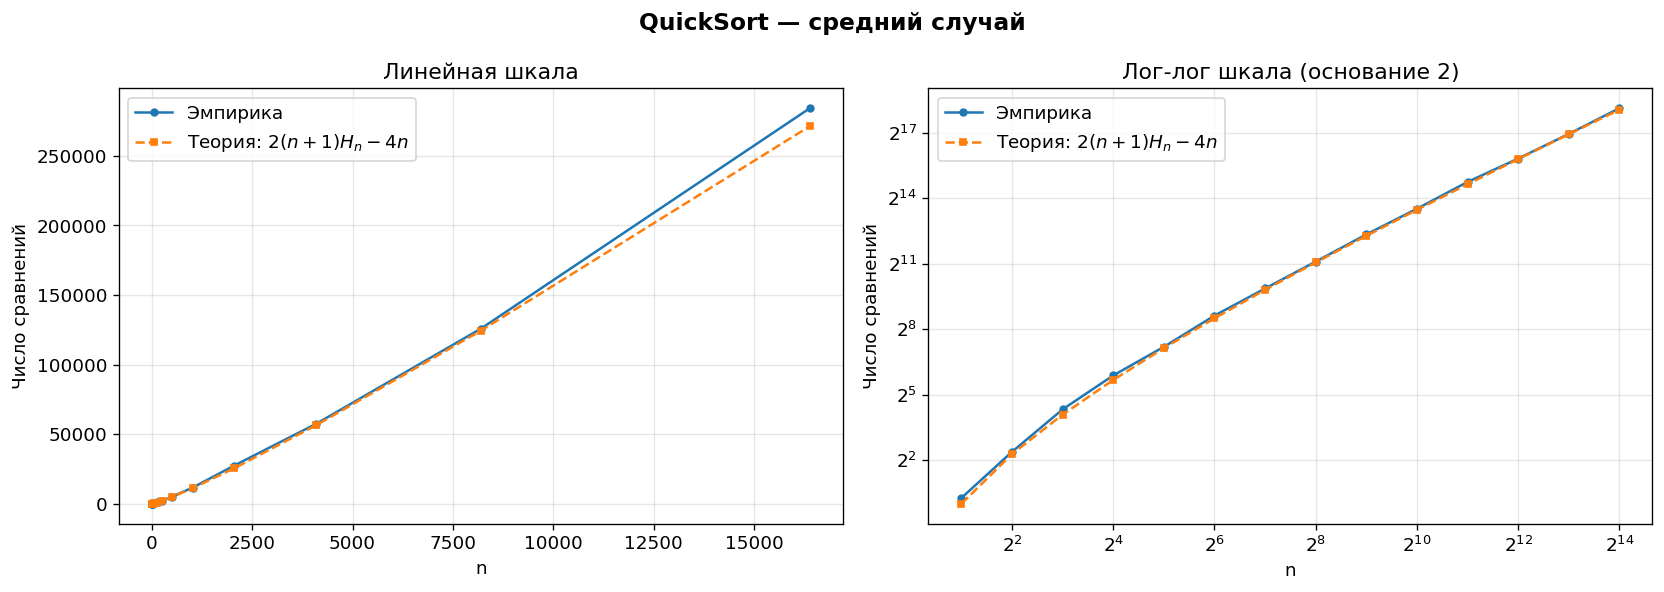

In [16]:
plot_comparison(
    SIZES,
    results['quick_avg']['emp'],
    results['quick_avg']['theory'],
    'QuickSort — средний случай',
    r'$2(n+1)H_n - 4n$'
)

### 4.6 Insertion Sort — худший случай

Формула: $T(n) = \frac{n(n-1)}{2}$

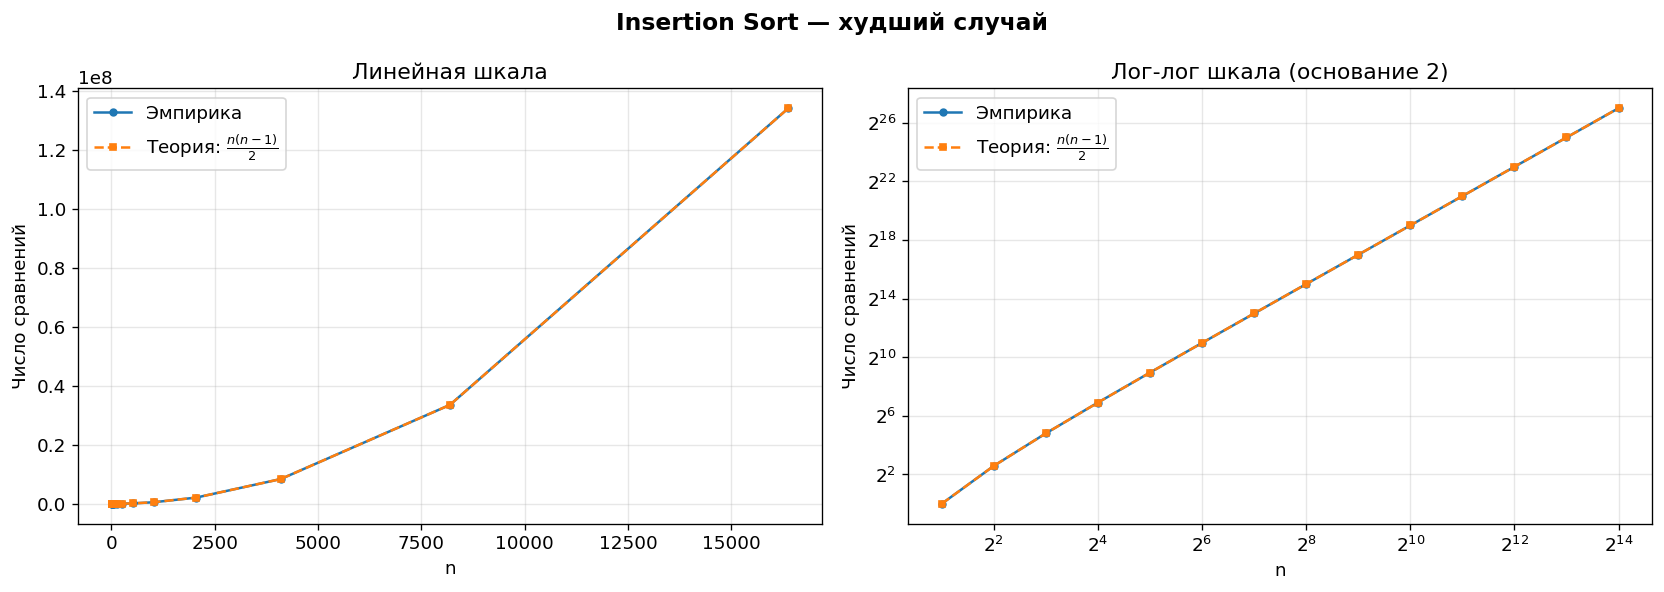

In [17]:
ins_sizes = [s for s in SIZES if s <= INSERTION_LIMIT]
plot_comparison(
    ins_sizes,
    results['insertion']['emp'],
    results['insertion']['theory'],
    'Insertion Sort — худший случай',
    r'$\frac{n(n-1)}{2}$'
)

### 4.7 Heap Sort

Верхняя оценка через прямую сумму: $\sum 2\lfloor\log_2 i\rfloor$

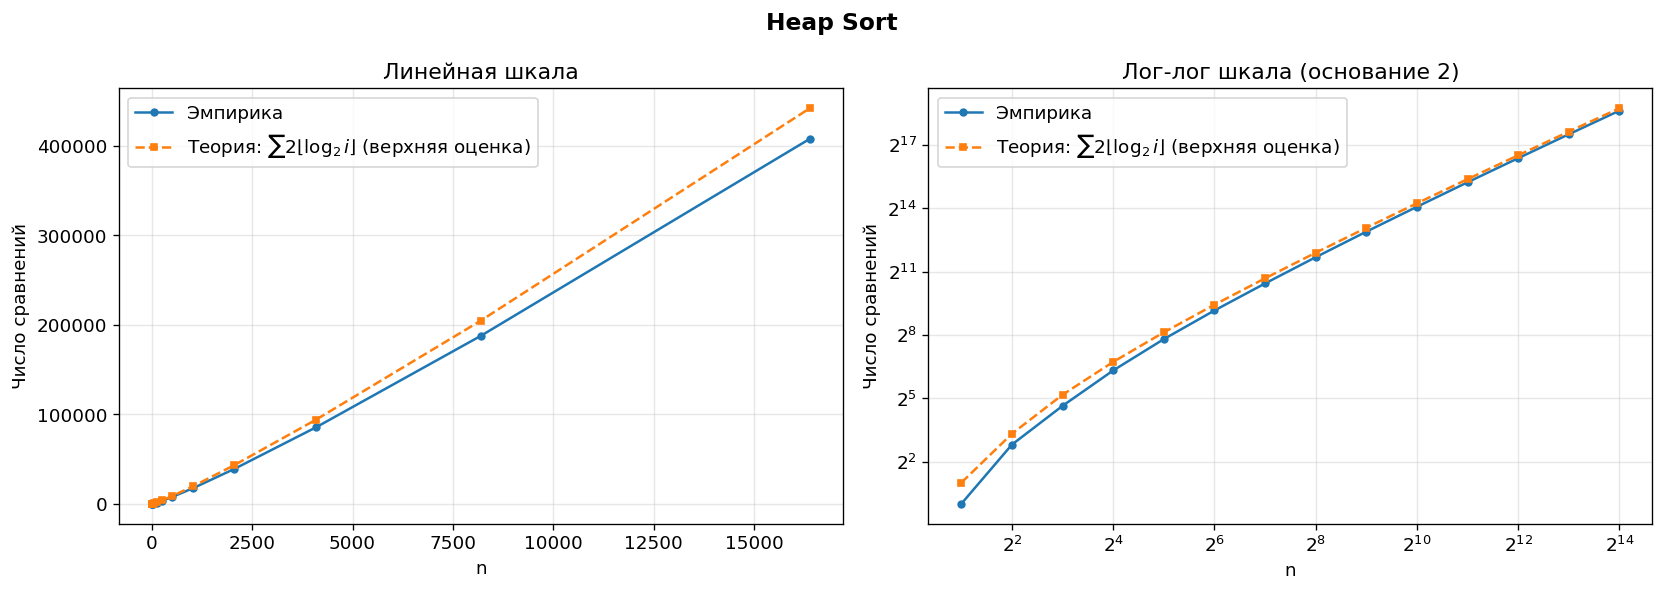

In [18]:
plot_comparison(
    SIZES,
    results['heap']['emp'],
    results['heap']['theory'],
    'Heap Sort',
    r'$\sum 2\lfloor\log_2 i\rfloor$ (верхняя оценка)'
)

### 4.8 Stooge Sort

Формула: $T(n) \in \Theta(n^{\log_{3/2} 3}) \approx \Theta(n^{2.709})$

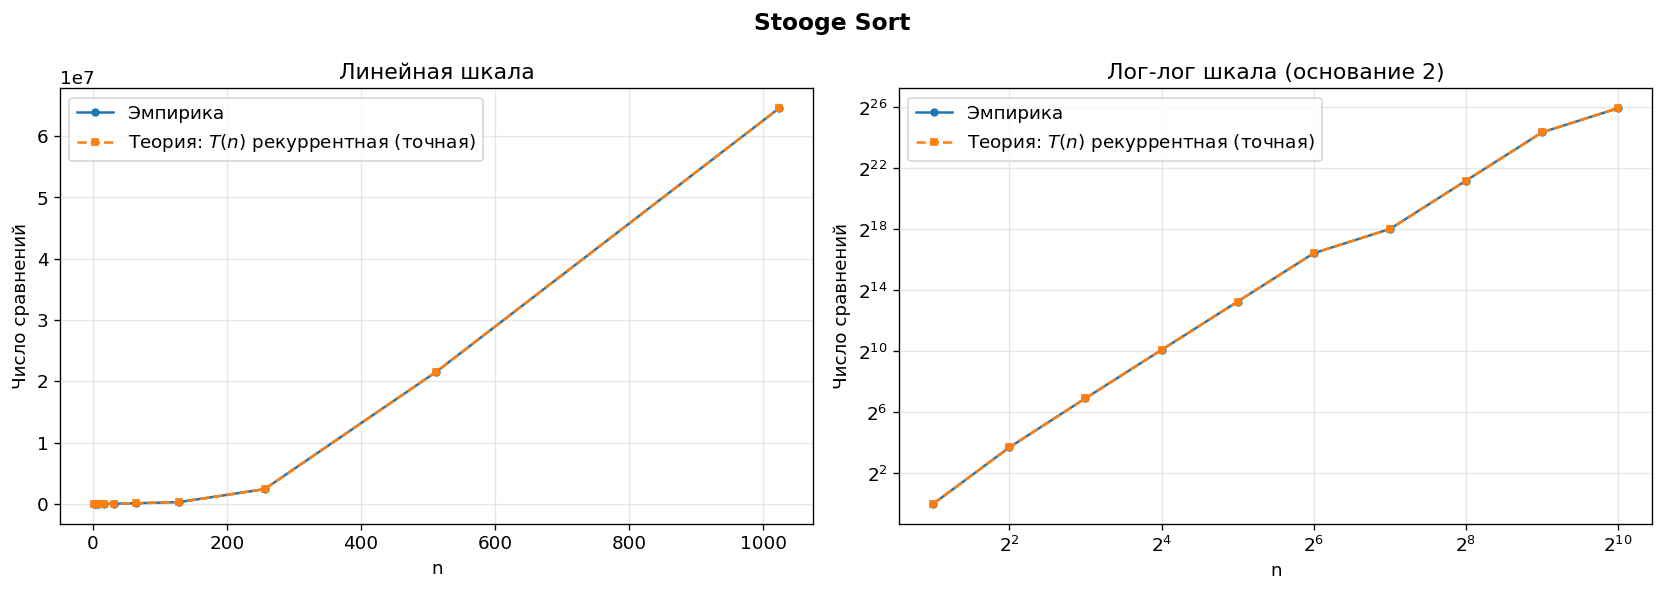

In [19]:
stooge_sizes = [s for s in SIZES if s <= STOOGE_LIMIT]
plot_comparison(
    stooge_sizes,
    results['stooge']['emp'],
    results['stooge']['theory'],
    'Stooge Sort',
    r'$T(n)$ рекуррентная (точная)'
)

---
## 5. Сводный график: все алгоритмы

Эмпирическое число сравнений в логарифмических координатах.

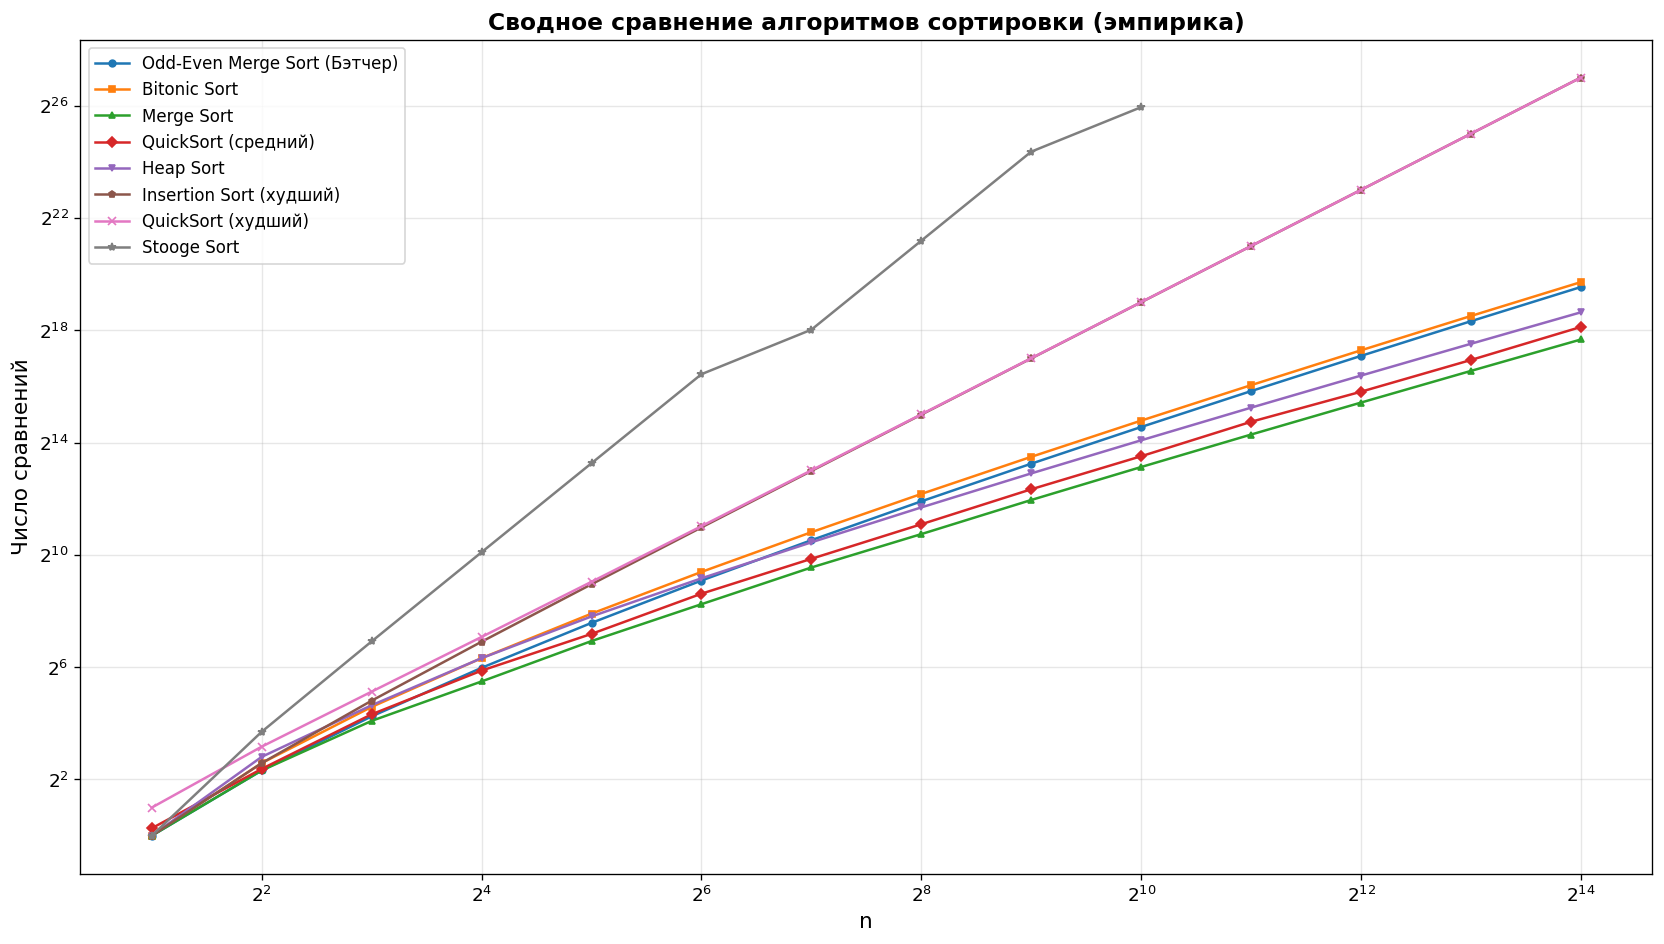

In [20]:
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(SIZES, results['batcher']['emp'],     'o-',  label='Odd-Even Merge Sort (Бэтчер)', markersize=4)
ax.plot(SIZES, results['bitonic']['emp'],      's-',  label='Bitonic Sort', markersize=4)
ax.plot(SIZES, results['merge']['emp'],        '^-',  label='Merge Sort', markersize=4)
ax.plot(SIZES, results['quick_avg']['emp'],    'D-',  label='QuickSort (средний)', markersize=4)
ax.plot(SIZES, results['heap']['emp'],         'v-',  label='Heap Sort', markersize=4)

ins_sizes = [s for s in SIZES if s <= INSERTION_LIMIT]
ax.plot(ins_sizes, results['insertion']['emp'], 'p-',  label='Insertion Sort (худший)', markersize=4)

ax.plot(SIZES, results['quick_worst']['emp'],  'x-',  label='QuickSort (худший)', markersize=5)

stooge_sizes = [s for s in SIZES if s <= STOOGE_LIMIT]
ax.plot(stooge_sizes, results['stooge']['emp'], '*-',  label='Stooge Sort', markersize=5)

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.set_xlabel('n', fontsize=13)
ax.set_ylabel('Число сравнений', fontsize=13)
ax.set_title('Сводное сравнение алгоритмов сортировки (эмпирика)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Таблица отклонений: эмпирика vs теория

Для сортировочных сетей (Бэтчер, Bitonic) число сравнений **фиксировано** — отклонение должно быть **ровно 0**.

In [21]:
print(f'{"n":>6s} | {"Бэтчер emp":>12s} {"теор":>10s} {"Δ":>6s} | '
      f'{"Bitonic emp":>12s} {"теор":>10s} {"Δ":>6s} | '
      f'{"MergeSort emp":>14s} {"теор":>10s}')
print('-' * 105)

for i, n in enumerate(SIZES):
    be = results['batcher']['emp'][i]
    bt = results['batcher']['theory'][i]
    bie = results['bitonic']['emp'][i]
    bit = results['bitonic']['theory'][i]
    me = results['merge']['emp'][i]
    mt = results['merge']['theory'][i]
    print(f'{n:>6d} | {be:>12d} {bt:>10.0f} {be - bt:>6.0f} | '
          f'{bie:>12d} {bit:>10.0f} {bie - bit:>6.0f} | '
          f'{me:>14d} {mt:>10.1f}')

     n |   Бэтчер emp       теор      Δ |  Bitonic emp       теор      Δ |  MergeSort emp       теор
---------------------------------------------------------------------------------------------------------
     2 |            1          1      0 |            1          1      0 |              1        1.0
     4 |            5          5      0 |            6          6      0 |              5        5.0
     8 |           19         19      0 |           24         24      0 |             17       17.0
    16 |           63         63      0 |           80         80      0 |             45       49.0
    32 |          191        191      0 |          240        240      0 |            122      129.0
    64 |          543        543      0 |          672        672      0 |            303      321.0
   128 |         1471       1471      0 |         1792       1792      0 |            750      769.0
   256 |         3839       3839      0 |         4608       4608      0 |           1

---
## 7. Выводы

1. **Odd-Even Merge Sort (Бэтчер)** — эмпирическое число сравнений **точно совпадает** с формулой $S(n) = \frac{n \log_2 n (\log_2 n - 1)}{4} + n - 1$ из Документа 02.

2. **Bitonic Sort** — аналогично, точное совпадение с $S_B(n) = \frac{n \log_2 n (\log_2 n + 1)}{4}$.

3. **Merge Sort** — число сравнений близко к $n \log_2 n - n + 1$.

4. **QuickSort (худший)** — точное совпадение с $\frac{n(n-1)}{2}$.

5. **QuickSort (средний)** — усреднённое число сравнений хорошо приближается формулой $2(n+1)H_n - 4n$.

6. **Insertion Sort (худший)** — точное совпадение с $\frac{n(n-1)}{2}$.

7. **Stooge Sort** — совпадение с рекуррентной формулой, рост $\Theta(n^{2.709})$.

8. **Heap Sort** — число сравнений ниже верхней оценки, но того же порядка $\Theta(n \log n)$.